 # Statement

 The Sure Tomorrow insurance company wants to solve several tasks with the help of ML and you are asked to evaluate that possibility.



 - Task 1: Find similar customers for a given customer. That can help the company's agents with their marketing.

 - Task 2: Predict whether a new customer is likely to receive an insurance benefit. Can a prediction model do better than a dummy model?

 - Task 3: Predict the number of insurance benefits a new customer is likely to receive. It needs to be solved with a linear regression model.

 - Task 4: Protect clients' personal data without breaking the model from the previous task. It is required to develop a data transformation algorithm that would make it hard to recover personal information from the transformed data, and the quality of model using the transformed date would not suffer. You don't need to tune your model into the best one, just prove that the algorithm works correctly.

 # Initialization

In [2]:
# %%
import itertools
import math
import random

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split


 # Load Data

 Load data and conduct basic checks it's free from obvious issues.

In [3]:
# %%
df = pd.read_csv('https://code.s3.yandex.net/datasets/insurance_us.csv')


 We rename the colums to make the code look more consistent with its style.

In [4]:
# %%
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})


In [5]:
# %%
df.sample(10)


,gender,age,income,family_members,insurance_benefits
1480,0,42.0,31900.0,1,1
2197,1,39.0,42300.0,0,0
1808,0,36.0,56000.0,2,0
1919,1,22.0,32800.0,0,0
1021,1,39.0,50300.0,2,0
4510,0,26.0,57100.0,1,0
4749,1,33.0,49600.0,2,0
4179,0,35.0,27900.0,0,0
1758,1,23.0,33100.0,1,0
1165,0,33.0,37200.0,0,0


In [6]:
# %%
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [7]:
# %%
# we may want to fix the age type (from float to int) though this is not critical

# checking all age values are integers indeed and do the conversion if so
if (df['age'] % 1 > 0).sum() == 0:
    df['age'] = df['age'].astype('int')


In [8]:
# %%
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [9]:
# %%
df.describe()


,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


 The data looks good, free of typical issues like missing values, extreme values and type mismatches. Proceeding.

 # EDA

 Let's quickly check whether there are certain groups of customers by looking at the pair plot.

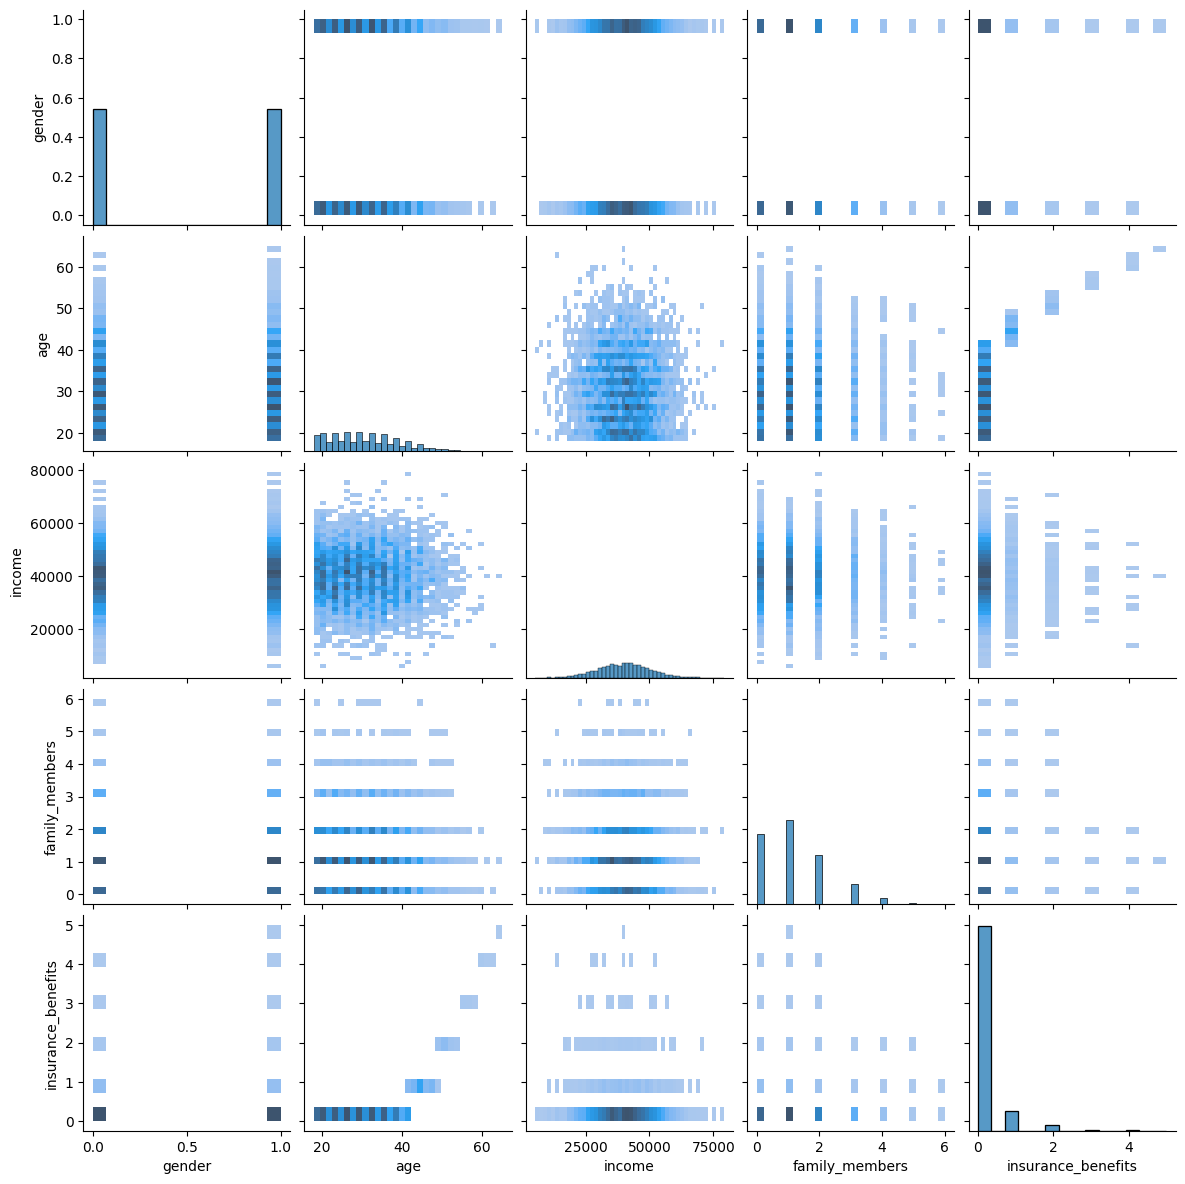

In [10]:
# %%
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)


 Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

 # Task 1. Similar Customers

 In the language of ML, it is required to develop a procedure that returns k nearest neighbors (objects) for a given object based on the concept of distance (between objects).



 You may want to review the following lessons to revive knowledge related to this chapter (chapter -> lesson)

 - Distance Between Vectors -> Planar Distance

 - Distance Between Vectors -> Manhattan Distance



 The interpretation of the task gives us possibility to try different distance metrics.

 Write a function that returns k nearest neighbors for a nth object based on a specified distance metric, the number of received insurance benefits should not be taken into account for the task.



 You can use a ready implementation of the kNN algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) or use your own.



 Test it for four combination of two cases

 - Scaling

   - the data is not scaled

   - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler

 - Distance Metrics

   - Euclidean

   - Manhattan



 Answer questions

 - Does the data being not scaled affect the kNN algorithm? If so, how does that appear?

 - Does the Manhattan distance metric return very similar results regardless the scaling?

In [11]:
# %%
feature_names = ['gender', 'age', 'income', 'family_members']


In [12]:
# %%
def get_knn(df, n, k, metric):
    
    """
    Returns k nearest neighbors

    :param df: pandas dataframe used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, algorithm='brute', metric=metric).fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res


 Scaling the data.

In [13]:
# %%
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_39186/808508866.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_39186/808508866.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [14]:
# %%
df_scaled.sample(5)


,gender,age,income,family_members,insurance_benefits
816,0,0.430769,0.417722,0.000000,0
303,1,0.430769,0.467089,0.166667,0
1256,0,0.476923,0.721519,0.000000,0
3965,1,0.292308,0.410127,0.166667,0
3829,0,0.415385,0.502532,0.166667,0


 Now, let's get similar records for a given one for every combination

In [15]:
# %%
k=5
n = random.randint(0, len(df_scaled))

for df_source, metric in itertools.product([df, df_scaled], ['euclidean', 'manhattan']):

    if df_source is not df_scaled:
        is_scaled = False
    else:
        is_scaled = True
        
    print(f'metric={metric}, scaled={is_scaled}')
    
    # getting the nearest neighbors
    df_nn = get_knn(df_source, n=n, k=5, metric=metric)
    
    # if this is the scaled data, let's add the original data to the result (easier to compare)
    if is_scaled:        
        df_nn = pd.concat([df.loc[df_nn.index], df_nn], axis=1, keys=['original', 'scaled'])
        
    (df_nn)
    print()


metric=euclidean, scaled=False

metric=manhattan, scaled=False

metric=euclidean, scaled=True

metric=manhattan, scaled=True



/Users/juliokorleone/anaconda3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/juliokorleone/anaconda3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/juliokorleone/anaconda3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/juliokorleone/anaconda3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


 Answers to the questions

 **Does the data being not scaled affect the kNN algorithm? If so, how does that appear?**



 There are different results returned by kNN for the original data and the scaled one with the same distance metric. In case of not scaling the data, kNN treat values of _income_ and _family_members_ equally important regardless of the fact their values are of very different ranges, and that forces customers with the same income but a different number of family members appear as similar whereas it is unlikely to be so in the real life. In the case of scaling the data, the variables become comparable, and results are much more consistent with what we can see in the real-life: customers of similar age and with similar number of family members but slightly different income appear together.

 **Does the Manhattan distance metric return very similar results regardless the scaling?**



 Yes, it does. The distance metric is affected by the scaling. The effect is the same as above. Minimal numerical difference is taken as advantage regardless of how variables might be different with their values.

 # Task 2. Is Customer Likely to Receive Insurance Benefit?

 In the world of ML, let's treat it as the binary classification task.

 With _insurance_benefits_ being more than zero as the target, evaluate whether the kNN classification approach can do better than a dummy model.



 Instructions:

 - Build a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. That'd be interesting to see how k may influece the evaluation metric, and whether scaling the data makes any difference. You can use a ready implemention of the kNN classification algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) or use your own.

 - Build the dummy model which is just a random one for this case. It returns "1" with some probability. Let's test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1.



 The probability of paying any insurance benefit can be defined as



 $$

 P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.

 $$



 Split the whole data in the 70:30 proportion for the training/testing parts.

In [16]:
# %%
# calculating the target

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype('int')


In [17]:
# %%
# checking for the class imbalance

df['insurance_benefits_received'].value_counts()


insurance_benefits_received
0    4436
1     564
Name: count, dtype: int64

 The data is imbalanced but let's see whether the algorithm will manage to solve this task without upsamling.

In [18]:
# %%



In [19]:
# %%
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)


In [20]:
# %%
# generating output of a random model

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)


In [21]:
# %%



In [22]:
# %%
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'The probability: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df))
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()


The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

The probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

The probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

The probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



In [23]:
# %%



In [24]:
# %%
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits_received'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

for n_neighbors in range(1, 11):
    
    print(f'n_neighbors={n_neighbors}')
    neigh = sklearn.neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)
    neigh.fit(X_train, y_train)

    y_test_pred = neigh.predict(X_test)
    
    eval_classifier(y_test, y_test_pred)    
    
    print()


n_neighbors=1
F1: 0.61
Confusion Matrix
[[0.87133333 0.02      ]
 [0.05266667 0.056     ]]

n_neighbors=2
F1: 0.41
Confusion Matrix
[[0.88733333 0.004     ]
 [0.08       0.02866667]]

n_neighbors=3
F1: 0.41
Confusion Matrix
[[0.87933333 0.012     ]
 [0.078      0.03066667]]

n_neighbors=4
F1: 0.28
Confusion Matrix
[[0.88866667 0.00266667]
 [0.09066667 0.018     ]]

n_neighbors=5
F1: 0.27
Confusion Matrix
[[0.88533333 0.006     ]
 [0.09066667 0.018     ]]

n_neighbors=6
F1: 0.11
Confusion Matrix
[[0.89       0.00133333]
 [0.102      0.00666667]]

n_neighbors=7
F1: 0.11
Confusion Matrix
[[0.88866667 0.00266667]
 [0.102      0.00666667]]

n_neighbors=8
F1: 0.07
Confusion Matrix
[[0.89133333 0.        ]
 [0.10466667 0.004     ]]

n_neighbors=9
F1: 0.08
Confusion Matrix
[[0.89133333 0.        ]
 [0.104      0.00466667]]

n_neighbors=10
F1: 0.00
Confusion Matrix
[[0.89133333 0.        ]
 [0.10866667 0.        ]]



In [25]:
# %%



In [26]:
# %%
X = df_scaled[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits_received'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

for n_neighbors in range(1, 11):
    
    print(f'n_neighbors={n_neighbors}')
    neigh = sklearn.neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)
    neigh.fit(X_train, y_train)

    y_test_pred = neigh.predict(X_test)
    
    eval_classifier(y_test, y_test_pred)    
    
    print()


n_neighbors=1
F1: 0.97
Confusion Matrix
[[0.88866667 0.00266667]
 [0.00466667 0.104     ]]

n_neighbors=2
F1: 0.93
Confusion Matrix
[[8.90666667e-01 6.66666667e-04]
 [1.40000000e-02 9.46666667e-02]]

n_neighbors=3
F1: 0.95
Confusion Matrix
[[0.88933333 0.002     ]
 [0.00866667 0.1       ]]

n_neighbors=4
F1: 0.91
Confusion Matrix
[[0.88933333 0.002     ]
 [0.01666667 0.092     ]]

n_neighbors=5
F1: 0.92
Confusion Matrix
[[0.88666667 0.00466667]
 [0.01133333 0.09733333]]

n_neighbors=6
F1: 0.90
Confusion Matrix
[[0.89       0.00133333]
 [0.018      0.09066667]]

n_neighbors=7
F1: 0.92
Confusion Matrix
[[0.88733333 0.004     ]
 [0.01266667 0.096     ]]

n_neighbors=8
F1: 0.90
Confusion Matrix
[[0.88866667 0.00266667]
 [0.01733333 0.09133333]]

n_neighbors=9
F1: 0.92
Confusion Matrix
[[0.88866667 0.00266667]
 [0.01466667 0.094     ]]

n_neighbors=10
F1: 0.88
Confusion Matrix
[[0.88866667 0.00266667]
 [0.02133333 0.08733333]]



 It is interesting to note the classification is the best (according to F1) with just k=1, kNN is quite good for this task. Scaling the data can increase the quality significantly, and it is a must. The random model behaves much worse than the kNN one.

 # Task 3. Regression (with Linear Regression)

 With _insurance_benefits_ as the target, evaluate what RMSE would be for a Linear Regression model.

 Build your own implementation of LR. For that, recall how the linear regression task's solution is formulated in terms of LA. Check RMSE for both the original data and the scaled one. Can you see any difference in RMSE between these two cases?



 Let's denote

 - $X$ — feature matrix, each row is a case, each column is a feature, the first column consists of unities

 - $y$ — target (a vector)

 - $\hat{y}$ — estimated tagret (a vector)

 - $w$ — weight vector



 The task of linear regression in the language of matrices can be formulated as



 $$

 y = Xw

 $$



 The training objective then is to find such $w$ that it would minimize the L2-distance (MSE) between $Xw$ and $y$:



 $$

 \min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)

 $$



 It appears that there is analytical solution for the above:



 $$

 w = (X^T X)^{-1} X^T y

 $$



 The formula above can be used to find the weights $w$ and the latter can be used to calculate predicted values



 $$

 \hat{y} = X_{val}w

 $$

 Split the whole data in the 70:30 proportion for the training/validation parts. Use the RMSE metric for the model evaluation.

In [27]:
# %%
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y

    def predict(self, X):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2 @ self.weights
        
        return y_pred


In [28]:
# %%



In [29]:
# %%
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')


In [30]:
# %%



In [31]:
# %%
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)


[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.66


In [32]:
# %%
X = df_scaled[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)


[-0.94353901  2.32372069  0.01642727 -0.02059875 -0.07014128]
RMSE: 0.34
R2: 0.66


 # Task 4. Hiding Data

 It is suggested to obfuscate data by multiplying the numerical features (remember, they can be seen as the matrix $X$) by an invertible matrix $P$.



 $$

 X' = X \times P

 $$



 Try to do that and check how the features' values will look like after the transformation. BTW, the intertible property is important here so make sure that $P$ is invertible indeed.



 You may want to review the 'Matrices and Matrix Operations -> Matrix Mupliplication' lesson to recall the rule of matrix multiplication and its implementation with numpy.

In [ ]:
# %%
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]


In [ ]:
# %%
X = df_pn.to_numpy()


 Generating a random matrix P.

Comentarios IRA

Por que generamos una matriz cuadrada? (por qué usamos .shape[1] dos veces)

- Para que la multiplicación A @ B sea válida, el número de columnas de A debe ser igual al número de filas de B
- para poder sacar la inversa: necesitamos una matriz cuadrada para poder calcular su inversa, Si no es cuadrada, no tiene inversa

In [ ]:
# %%
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))


 Checking the matrix $P$ is invertible

In [ ]:
# %%
P_det = np.linalg.det(P)

# if a matrix's determinant is not equal to zero, it is invertible
print(P_det)


0.24339135998015468


 Transforming the data

In [ ]:
# %%
Xt = X @ P


 Can you guess of age, income after the transformation?

In [ ]:
# %%
dft = pd.DataFrame(Xt, columns=df_pn.columns)
df2 = pd.concat([df, dft], axis=1, keys=['original', 'transformed'])


In [ ]:
# %%
df2.sample(5)


original                                                 \
       gender age   income family_members insurance_benefits   
4562        0  24  56200.0              0                  0   
4854        1  22  30300.0              1                  0   
2864        1  37  45100.0              2                  0   
4967        1  23  29000.0              2                  0   
1360        0  37  45200.0              3                  0   

                                  transformed                              \
     insurance_benefits_received       gender           age        income   
4562                           0  7202.246413  25335.104646  20857.116315   
4854                           0  3885.332793  13669.419250  11253.227220   
2864                           0  5783.471082  20350.588228  16752.898488   
4967                           0  3719.523113  13085.715915  10772.394342   
1360                           0  5796.152354  20396.010705  16789.563107   

                     
     family_members  
4562   52103.057917  
4854   28099.197184  
2864   41827.337222  
4967   26895.416001  
1360   41919.543591

 No, it is difficult to guess it by just looking at it.

 Can you recover the original data from $X'$ if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.

 Reversed transformation

In [ ]:
# %%
P_inv = np.linalg.inv(P)


In [ ]:
# %%
Xn = Xt @ P_inv


In [ ]:
# %%
dfn = pd.DataFrame(Xn, columns=df_pn.columns)
df3 = pd.concat([df_pn, dft, dfn], axis=1, keys=['original', 'transformed', 'reversed'])


 Print all three cases for few customers

 - the original data

 - the transformed one

 - the reversed (recovered) one

In [ ]:
# %%
df3.sample(5)


original                              transformed                \
       gender age   income family_members       gender           age   
31          1  40  30300.0              0  3886.384120  13686.157691   
366         1  34  46300.0              2  5936.924909  20888.124486   
4743        1  26  20100.0              2  2579.594314   9080.207935   
3023        0  49  40600.0              1  5206.672042  18334.297335   
2164        0  22  46600.0              3  5974.098780  21011.916683   

                                       reversed                                
            income family_members        gender   age   income family_members  
31    11266.484320   28113.119102  1.000000e+00  40.0  30300.0   4.596967e-12  
366   17195.572698   42937.097016  1.000000e+00  34.0  46300.0   2.000000e+00  
4743   7474.575346   18649.565793  1.000000e+00  26.0  20100.0   2.000000e+00  
3023  15092.139043   37665.402937  1.741269e-12  49.0  40600.0   1.000000e+00  
2164  17297.263245   43205.223611  4.513260e-12  22.0  46600.0   3.000000e+00

 Let's try to make figures a bit easier to read

In [ ]:
# %%
df3.sample(5).astype('int')


original                           transformed                \
       gender age income family_members      gender    age income   
1925        1  45  35800              0        4591  16168  13309   
4840        1  31  45700              1        5859  20614  16970   
2386        0  38  46200              2        5923  20846  17160   
2719        0  40  52100              3        6680  23506  19350   
4983        0  26  47800              2        6127  21555  17744   

                    reversed                            
     family_members   gender age income family_members  
1925          33214        1  44  35800              0  
4840          42378        1  31  45699              0  
2386          42846        0  37  46200              2  
2719          48316        0  39  52099              3  
4983          44320        0  25  47800              2

 You can probably see that some values are not exactly the same as they are in the original data. What is a reason for that?

 All integer values were converted to float because during the transformation all figures got fractional part.



 Some values are not exactly zeros as in the original data because of the precision limitation.

 Let's check whether the features' original/transformed values correlate

In [ ]:
# %%
import scipy.stats

for name in personal_info_column_list:
    r, p = scipy.stats.spearmanr(df3['original'][name], df3['transformed'][name])
    print(f'{name:15} r={r:5.2f}, p={p:.2f}')


gender          r= 0.01, p=0.36
age             r=-0.02, p=0.22
income          r= 1.00, p=0.00
family_members  r=-0.03, p=0.07


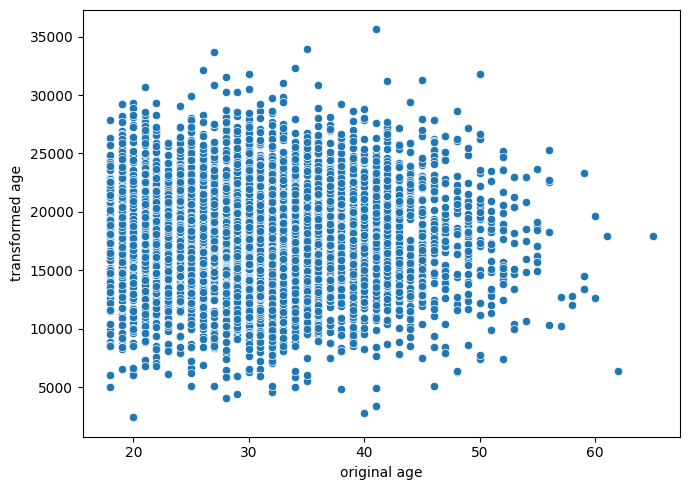

In [ ]:
# %%
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=df3['original']['age'], y=df3['transformed']['age'], ax=ax)
ax.set_xlabel('original age')
ax.set_ylabel('transformed age')

fig.tight_layout()


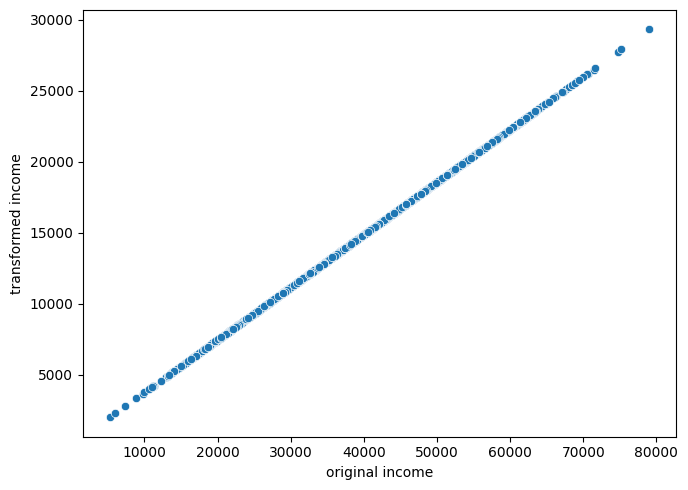

In [ ]:
# %%
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(x=df3['original']['income'], y=df3['transformed']['income'], ax=ax)
ax.set_xlabel('original income')
ax.set_ylabel('transformed income')

fig.tight_layout()


 ## Proof That Data Obfuscation Can Work with LR

 The regression task has been solved with linear regression in this project. Your next task is to prove _analytically_ that the given obfuscation method won't affect linear regression in terms of predicted values i.e. their values will remain the same. Can you believe that? Well, you don't have to, you should prove it!

 So, the data is obfuscated and there is $X \times P$ instead of just $X$ now. Consequently, there are other weights $w_P$ as

 $$

 w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y

 $$



 How would $w$ and $w_P$ be linked if you simplify the formula for $w_P$ above?



 What would be predicted values with $w_P$?



 What does that mean for the quality of linear regression if you measure it with RMSE?



 Check Appendix B Properties of Matrices in the end of the notebook. There are useful formulas in there!



 No code is necessary in this section!

 **Answer**

 The quality of Linear Regression as measured with RMSE or R2 is not changed because of the transformation.

 **Analytical proof**

 $$

 \begin{align}

 w_P &= [(XP)^T XP]^{-1} (XP)^T y \\

     &= [P^T X^T X P]^{-1} (XP)^T y \\

     &= [(P^T X^T X) P]^{-1} (XP)^T y \\

     &= P^{-1} [P^T X^T X]^{-1} (XP)^T y \\

     &= P^{-1} [X^T X]^{-1} [P^T]^{-1} (XP)^T y \\

     &= P^{-1} [X^T X]^{-1} [P^T]^{-1} P^T X^T y \\

     &= P^{-1} [X^T X]^{-1} I X^T y \\

     &= P^{-1} [X^T X]^{-1} X^T y \\

     &= P^{-1} \boxed{[X^T X]^{-1} X^T y}

 \end{align}

 $$

 So, we have derived that

 $$w_P = P^{-1} [X^T X]^{-1} X^T y $$

 or

 $$

 \begin{align}

 w_P &= P^{-1} w \\

 P w_P &= P P^{-1} w \\

 P w_P &= w \\

 w &= P w_P \\

 \end{align}

 $$

 Accordingly

 $$\hat{y} = X w = X P w_p = \boxed{X' w_P}$$

 One can see that the predicted value are not changed so any evaluation metrics that compare true values and predicted ones will return same values regardless of the transformation.

 ## Test Linear Regression With Data Obfuscation

 Now, let's prove Linear Regression can work with the chosen obfuscation transformation computationally.



 Build a procedure or a class that runs Linear Regression optionally with the obfuscation. You can use either a ready implementation of Linear Regression from sciki-learn or your own.



 Run Linear Regression for the original data and the obfuscated one, compare the predicted values and the RMSE, $R^2$ metric values. Is there any difference?

 **Procedure**



 - Create a square matrix $P$ of random numbers

 - Check that it is invertible. If not, repeat the generation until we get an invertible matrix..

 - Multiply the feature matrix $X$ by matrix $P$

 - Use $XP$ as the new feature matrix

 **Validation**



 We will use results of the previous paragraph: that when multiplying features by an invertible matrix, the quality of the linear regression as measured with MSE will not change. But multiplying by random numbers will make the initial values unrecoverable without knowing the random matrix.

In [ ]:
# %%
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)


In [ ]:
# %%



In [ ]:
# %%
model = sklearn.linear_model.LinearRegression()

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

eval_regressor(y_test, y_pred_test)


RMSE: 0.34
R2: 0.66


In [ ]:
# %%



In [ ]:
# %%
det = 0
eps = 1e-5

while det < eps:
    rng = np.random.default_rng()
    P = rng.random(size=(X_train.shape[1], X_train.shape[1]))

    # let's check that the matrix is invertible
    det = np.linalg.det(P)

# if a matrix's determinant is not equal to zero, it is invertible
print(f'Generated the random matrix P with the determinant {det:.2f}')
print(P)
print()

Xt = X @ P

Xt_train = X_train @ P
Xt_test = X_test @ P


Generated the random matrix P with the determinant 0.11
[[0.34273257 0.87817738 0.2006488  0.22807735]
 [0.97282759 0.46993607 0.57571649 0.29765154]
 [0.77463688 0.01639199 0.1262451  0.43139146]
 [0.72078286 0.3962411  0.10197238 0.97510755]]



In [ ]:
# %%
model_t = sklearn.linear_model.LinearRegression()

model_t.fit(Xt_train, y_train)

yt_pred_train = model_t.predict(Xt_train)
yt_pred_test = model_t.predict(Xt_test)

eval_regressor(y_test, yt_pred_test)


RMSE: 0.34
R2: 0.66


 We can see that the evaluation metrics are the same for both the cases. Isn't that a fascinating example of LA?!

 # Conclusions

 - kNN is quite a simple algorithm but still capable for finding similar objects and the classification task.

 - Computation of matrix operations does not lead to exact figures as we calculate them on paper, this is because computers are limited with their computing precision.

 - Working with formulas can be both fun and useful.

 - It is possible to transform numerical features with an invertible matrix and they will still be useful for certain ML algorythms like linear tegression as the transformation does not affect predicted values.

 - Linear Algebra is a key component to Machine Learning, it allows organizing objects with their numerical features into matrices and use matrix operations to solve problems.

 # Checklist (TBC)

 Type 'x' to check. Then press Shift+Enter.

 - [x]  Jupyter Notebook is open

 - [ ]  Code is error free

 - [ ]  The cells are arranged in order of logic and execution

 - [ ]  Task 1 performed

     - [ ]  There is the procedure that can return k similar customers for a given one

     - [ ]  The procedure is tested for all four proposed combinations

     - [ ]  The questions re the scaling/distances are answered

 - [ ]  Task 2 performed

     - [ ]  The random classification model is built and tested for all for probability levels

     - [ ]  The kNN classification model is built and tested for both the original data and the scaled one, the F1 metric is calculated.

 - [ ]  Task 3 performed

     - [ ]  The linear tegression solution is implemented with matrix operations.

     - [ ]  RMSE is calculated for the implemented solution.

 - [ ]  Task 4 performed

     - [ ]  The data is obfuscated with a random and invertible matrix P

     - [ ]  The obfuscated data is recoved, few examples are printed out

     - [ ]  The analytical proof that the transformation does not affect RMSE is provided

     - [ ]  The computational proof that the transformation does not affect RMSE is provided

 - [ ]  Conclusions are made

 # Appendix A Writing Formulas in Jupyter Notebooks

 You can write formulas in Jupyter Notebook in a markup language provided by a high-quality publishing system called $\LaTeX$ (pronounced «Lah-tech»), and they will look like formulas in textbooks.



 To put a formula in a text, put the dollar sign (\\$) before and after the formula's text e.g. $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.



 If a formula should be in its paragraph, put the double dollar sign (\\$\\$) before and after the formula text e.g.



 $$

 \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.

 $$



 The markup language of [LaTeX](https://en.wikipedia.org/wiki/LaTeX) is very popular among people who use formulas in their articles, books and texts. It can be complex but its basics are easy. Check this two page [cheatsheet](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) for learning how to compose the most common formulas.

 # Appendix B Properties of Matrices

 Matrices have many properties in Linear Algebra. There are listed few of them here which can help with the analytical proof in this project.

 <table>

 <tr>

 <td>Distributivity</td><td>$A(B+C)=AB+AC$</td>

 </tr>

 <tr>

 <td>Non-commutativity</td><td>$AB \neq BA$</td>

 </tr>

 <tr>

 <td>Associative property of multiplication</td><td>$(AB)C = A(BC)$</td>

 </tr>

 <tr>

 <td>Multiplicative identity property</td><td>$IA = AI = A$</td>

 </tr>

 <tr>

 <td></td><td>$A^{-1}A = AA^{-1} = I$

 </td>

 </tr>

 <tr>

 <td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>

 </tr>

 <tr>

 <td>Reversivity of the transpose of a product of matrices,</td><td>$(AB)^T = B^TA^T$</td>

 </tr>

 </table>